# Preparation

In [1184]:
# %matplotlib widget
%config InlineBackend.figure_format = 'svg'

import os, math
from enum import IntEnum, auto
from collections import defaultdict, namedtuple, Counter, deque
from dataclasses import dataclass
import itertools
import sqlite3
import pickle
import datetime
import queue
import json
import decimal
from IPython.core.getipython import get_ipython

from PIL import Image, ImageDraw
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import scipy as sp
import numpy as np
import cupy as cp
import pandas as pd
from sklearn.preprocessing import StandardScaler

import sys
sys.path.append('../../lib')

from utils import *
from shared_types import SensorInstance

In [22]:
LOG = Logging()

config_var = 'SQLITE3_SEQ_GRID_0_2_4096'
config = Config(config_var)
# RNG = np.random.default_rng() 
RNG = np.random.default_rng(42)

if cp.cuda.is_available():
    xp = cp.get_array_module(cp.empty(1))
    xp_array_from_gpu = lambda a: a.get() if isinstance(a, cp.ndarray) else a
    xp_array_to_gpu = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
    xp_array_to_gpu_copy = lambda a: cp.asarray(a) if isinstance(a, np.ndarray) else a
else:
    xp = cp.get_array_module(np.empty(1))
    xp_array_from_gpu = lambda a: a
    xp_array_to_gpu = lambda a: a
    xp_array_to_gpu_copy = lambda a: a.copy()

print(f'xp={xp.__name__}')

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)

print(f'notebook={notebook_fname}')
LOG.app_name = os.path.splitext(notebook_fname)[0].upper()

xp=numpy
notebook=gp_test.ipynb


# Data Loading

In [23]:
%time
train_db_con = sqlite3.connect(DBUtils.get_full_db_file_name(config, config.train_db_file_name))

CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 8.34 μs


In [24]:
df_train_images = pd.read_sql_query('SELECT * FROM images', con=train_db_con, index_col='image_id')
df_train_images.shape

(10000, 7)

In [25]:
fetch_si_xy = lambda si: (si.x, si.y)
get_joint_sequence = lambda sequences: np.array(list(itertools.chain.from_iterable(sequences)))
get_sequences_reading = lambda sequences, seq_reading_code: list(map(lambda r: sequences[r[0]] if r[1] == 0 else list(reversed(sequences[r[0]])), seq_reading_code))
get_xy_sequence = lambda sequence, si_ind_dict: np.array(list(map(lambda si_ind: fetch_si_xy(si_ind_dict[si_ind]), sequence)))
get_raw_image = lambda image_id: Image.open(io.BytesIO((df_train_images if image_id < 100_000_000 else df_test_images).loc[image_id]['png']))


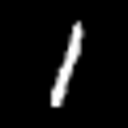
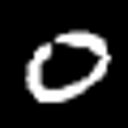
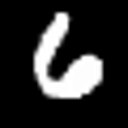
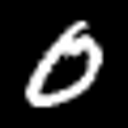
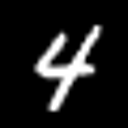
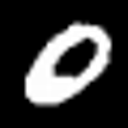
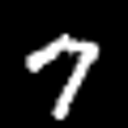
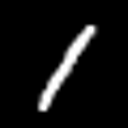

In [26]:
count = 8

def get_images_and_labels(df, ids):
    image_datas = df.loc[ids]['png']
    images = [Image.open(io.BytesIO(image_data)) for image_data in image_datas]
    labels = df.loc[ids]['value']
    return images, list(labels)

def get_some_random_images_and_labels(df, count):
    image_ids = RNG.choice(df.index.unique(), count, replace=False)
    return get_images_and_labels(df, image_ids)

train_images, train_labels = get_some_random_images_and_labels(df_train_images, count)

display_images_grid(train_images, captions=train_labels, col_count=count)

In [27]:
image = df_train_images[df_train_images.value == '5'].iloc[1]
sequences = pickle.loads(image.inner_sequences)
si_ind_dict = pickle.loads(image.inner_si_ind_dict)

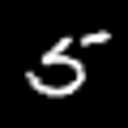

In [28]:
get_raw_image(image.name)

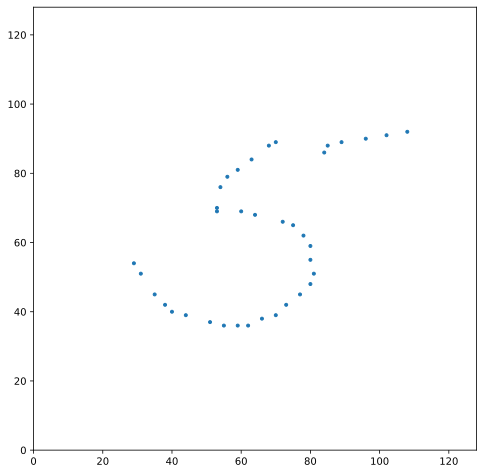

In [29]:
xy_list = get_xy_sequence(get_joint_sequence(sequences), si_ind_dict)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(xy_list[:,0], config.sample_size - xy_list[:,1], marker='.')
ax1.set_aspect('equal')
ax1.set(xlim=(0, config.sample_size), ylim=(0, config.sample_size));

In [30]:
center_pos = config.sample_size / 2
data = []

for seq in sequences:
    for si_ind_from, si_ind_to in zip(seq[:-1], seq[1:]):
        si_from = si_ind_dict[si_ind_from]
        si_to = si_ind_dict[si_ind_to]
        # -si_to.y + si_from.y == config.sample_size - si_to.y - (config.sample_size - si_from.y)
        data.append((
            si_from.x,
            config.sample_size - si_from.y, 
            # complex(si_to.x - si_from.x, -si_to.y + si_from.y),
            si_to.x - si_from.x,
            -si_to.y + si_from.y
        ))

data = np.array(data, dtype='f')
data[:,0] -= center_pos
data[:,1] -= center_pos
data /= config.sample_size
np.round(data[:5], decimals=2)

array([[-0.09,  0.05,  0.01,  0.05],
       [-0.08,  0.09,  0.02,  0.02],
       [-0.06,  0.12,  0.02,  0.02],
       [-0.04,  0.13,  0.03,  0.02],
       [-0.01,  0.16,  0.04,  0.03]], dtype=float32)

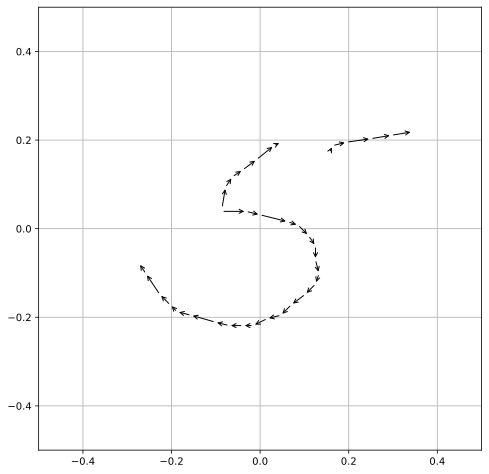

In [31]:
fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set(xlim=(-.5, .5), ylim=(-.5, .5));

for item in data:
    x_from, y_from = item[0], item[1]
    x_to, y_to = x_from + item[2], y_from + item[3]
    # x_from, y_from = item[0].real, item[1].real
    # x_to, y_to = x_from + item[2].real, y_from + item[2].imag
    ax1.annotate('', xytext=(x_from, y_from), xy=(x_to, y_to), arrowprops=dict(arrowstyle="->"))

# ax1.set(xlim=(0, config.sample_size), ylim=(0, config.sample_size));

# for seq in sequences:
#     for si_ind_from, si_ind_to in zip(seq[:-1], seq[1:]):
#         si_from = si_ind_dict[si_ind_from]
#         si_to = si_ind_dict[si_ind_to]
#         # x = (si_from.x + si_to.x) / 2
#         # y = config.sample_size - (si_from.y + si_to.y) / 2
#         # ax1.scatter(x, y, marker='.', color='C0')
#         ax1.annotate('', xytext=(si_from.x, config.sample_size - si_from.y), xy=(si_to.x, config.sample_size - si_to.y), arrowprops=dict(arrowstyle="->"))

# Brutefoce GP

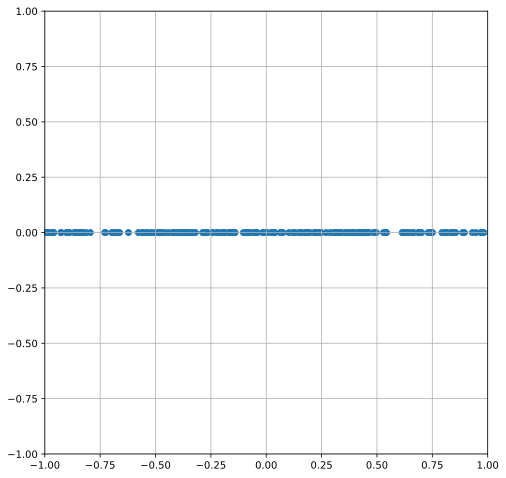

In [32]:
# Multimodal normal distribution
base_cov_mat = np.array([
    [1, 0],
    [0, 1],
])

scale_mat = np.array([[1, 0], [0, 1e-6]])
# scale_mat = np.eye(2)

def get_rot_mat(degrees):
    theta = np.deg2rad(degrees)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

rot_mat = get_rot_mat(0)
cov_mat1 = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

rot_mat = get_rot_mat(130)
cov_mat2 = rot_mat @ scale_mat @ scale_mat @ rot_mat.T

cov_mat = np.zeros((cov_mat1.shape[0] + cov_mat2.shape[0], cov_mat1.shape[0] + cov_mat2.shape[0]))
base_i, base_j = 0, 0
cov_mat[base_i:base_i+cov_mat1.shape[0], base_j:base_j+cov_mat1.shape[1]] = cov_mat1
base_i, base_j = cov_mat1.shape
cov_mat[base_i:base_i+cov_mat2.shape[0], base_j:base_j+cov_mat2.shape[1]] = cov_mat2

samples_count = 300

ys = RNG.multivariate_normal(
    mean=np.zeros(cov_mat.shape[0]),
    cov=cov_mat,
    size=samples_count)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(ys[:,0], ys[:,1], color='C0')
# ax1.scatter(ys[:,2], ys[:,3], color='C1')
#im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
# ax1.set_xlim(-.5, .5)
# ax1.set_ylim(-.5, .5)
# ax1.set_xticks(np.linspace(0, 29, 30))
# ax1.set_yticks(np.linspace(0, 29, 30))
ax1.set_xlim(-1, 1)
ax1.set_ylim(-1, 1)
ax1.set_aspect('equal')
ax1.grid()
# fig.colorbar(im, shrink=0.8, ax=ax1);

In [33]:
# Define the exponentiated quadratic 
def exponentiated_quadratic_kernel(xa, xb, ls=1):
    """Exponentiated quadratic with σ=1"""
    # L2 distance (Squared Euclidian)
    sq_norm = -sp.spatial.distance.cdist(xa, xb, 'sqeuclidean') / (2 * ls**2)
    return np.exp(sq_norm)

In [34]:
def linear_kernel(xa, xb, c=0, sigma_b=1, sigma_v=1):
    '''
    1) The offset "c" determines the x-coordinate of the point that all the lines
    in the posterior go though. At this point, the function will have zero
    variance (unless you add noise)
    2) The constant variance "sigma_b" determines how far from 0 the height of the
    function will be at zero. It's a little confusing, becuase it's not
    specifying that value directly, but rather putting a prior on it. It's
    equivalent to adding an uncertain offset to our model.
    3) The constant variance "sigma_v" is a prior on a slope.
    '''
    dist_func = lambda a, b: (sigma_b ** 2) + (sigma_v ** 2) * (a - c) @ (b - c)
    return sp.spatial.distance.cdist(xa, xb, dist_func)
    # return (sigma_b ** 2) + (sigma_v ** 2) * (xa - c) * (xb - c)

CPU times: user 3.47 s, sys: 17.8 ms, total: 3.49 s
Wall time: 334 ms


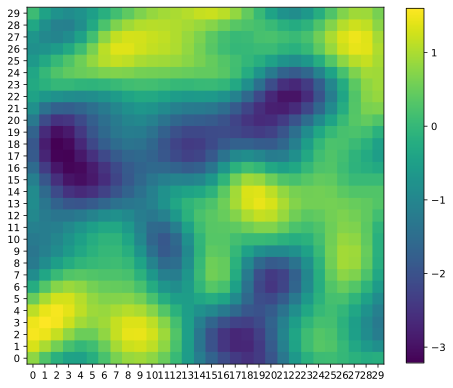

In [35]:
%%time
# Мы тут рассматриваем 2-х мерный случай: (x,y) -> значение пикселя grayscale (или on/off для BW).
# А это значит, что мы должны рассмотреть каждое сочетание из 30-и x с 30-и y. Т.е. точек будет 30х30
# Именно поэтому размер матрица ковариаций будет 900x900 и mean=np.zeros(samples_count**2)
# Если бы у нас был одномерный случай x->значение, то точек было тоже 30, а размер матрицы ковариаций был бы 30x30
# Если бы измерений было бы 3, то надо было бы рассматривать 30^3 точек = 27000

samples_count = 30
ticks = np.linspace(-.5, .5, samples_count)
base_coords = np.stack(np.meshgrid(ticks, ticks), axis=2).reshape(-1, 2)
cov_mat = exponentiated_quadratic_kernel(base_coords, base_coords, ls=0.1)
# cov_mat = linear_kernel(base_coords, base_coords, c=0, sigma_b=0.5, sigma_v=10)
cov_mat_factor_method = ['svd', 'cholesky'][0]

# ys (RV) has a samples_count**2 dimensions. So we need only 1 sample which will cover all pixels
ys = RNG.multivariate_normal(
    mean=np.zeros(samples_count**2),
    cov=cov_mat,
    method=cov_mat_factor_method)
# dist = sp.stats.multivariate_normal(
#     mean=None, 
#     cov=cov_mat,
#     allow_singular=True) # when there are many ticks (e.g. > 30), then cov_mat tends to be ill-conditioned
# ys = dist.rvs() 

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
ax1.set_xticks(np.linspace(0, 29, 30))
ax1.set_yticks(np.linspace(0, 29, 30))
fig.colorbar(im, shrink=0.8, ax=ax1);

In [39]:
# Gaussian process posterior with noisy obeservations
def GP_noise(X1, y1, X2, kernel_func, σ_noise):
    """
    Calculate the posterior mean and covariance matrix for y2
    based on the corresponding input X2, the noisy observations 
    (y1, X1), and the prior kernel function.
    """
    # Kernel of the noisy observations
    Σ11 = kernel_func(X1, X1) + ((σ_noise ** 2) * np.eye(len(X1)))
    # Kernel of observations vs to-predict
    Σ12 = kernel_func(X1, X2)
    # Solve
    solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
    # Compute posterior mean
    μ2 = solved @ y1
    # Compute the posterior covariance
    Σ22 = kernel_func(X2, X2)
    Σ2 = Σ22 - (solved @ Σ12)
    return μ2, Σ2  # mean, covariance

In [40]:
kernel_func = lambda x, y: exponentiated_quadratic_kernel(x, y, ls=0.05)

data_y = np.full(len(data), 3)
μ2, Σ2 = GP_noise(data[:,:2], data_y, base_coords, kernel_func, σ_noise=0.05)
σ2 = np.sqrt(np.diag(Σ2))

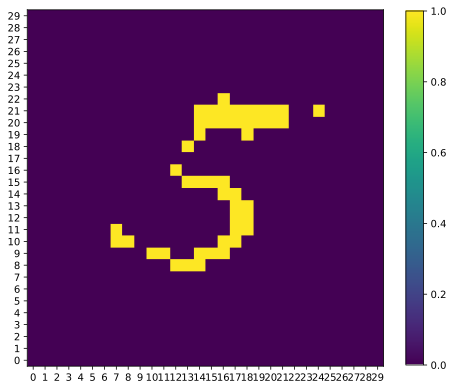

In [41]:
ys = RNG.multivariate_normal(
    mean=μ2,
    cov=Σ2,
    method=cov_mat_factor_method)
# ys = scipy.special.expit(ys)
# ys = np.where(ys > 0.5, 1, 0)
ys = np.where(ys > 2.9, 1, 0)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
im = ax1.imshow(ys.reshape(samples_count, -1), origin='lower')
ax1.set_xticks(np.linspace(0, 29, 30))
ax1.set_yticks(np.linspace(0, 29, 30))
fig.colorbar(im, shrink=0.8, ax=ax1);

# Manual craft of cov_mat

In [384]:
c = np.diag(np.full(6, 0.5))
c[2, 2] = 0.01
c[5, 5] = 0.01
c[2, 5] = 0.98 * np.sqrt(c[2, 2]) * np.sqrt(c[5, 5])
c[5, 2] = c[2, 5]


c[0, 3] = 0.95 * np.sqrt(c[0, 0]) * np.sqrt(c[3, 3])
c[3, 0] = c[0, 3]

c[1, 4] = 0.95 * np.sqrt(c[1, 1]) * np.sqrt(c[4, 4])
c[4, 1] = c[1, 4]

Text(0.5, 1.0, 'd=2.32')

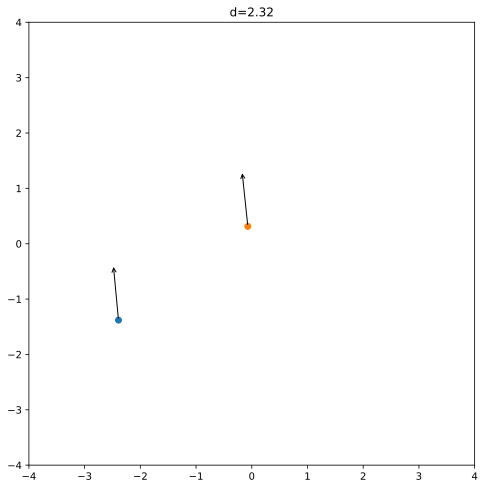

In [414]:
ys = RNG.multivariate_normal(
    mean=np.array([-1, -1, np.deg2rad(90), 1, 1, np.deg2rad(90)]), 
    cov=c, 
    size=1)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(8)
fig.set_figheight(8)
ax1.scatter(ys[0,0], ys[0,1])
ax1.scatter(ys[0,3], ys[0,4])
ax1.annotate('', xytext=(ys[0,0], ys[0,1]), xy=(ys[0,0] + np.cos(ys[0,2]), ys[0,1] + np.sin(ys[0,2])), arrowprops=dict(arrowstyle="->"), annotation_clip=False)
ax1.annotate('', xytext=(ys[0,3], ys[0,4]), xy=(ys[0,3] + np.cos(ys[0,5]), ys[0,4] + np.sin(ys[0,5])), arrowprops=dict(arrowstyle="->"), annotation_clip=False)
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.set_title(f'd={ys[0, 3]-ys[0, 0]:.2f}')

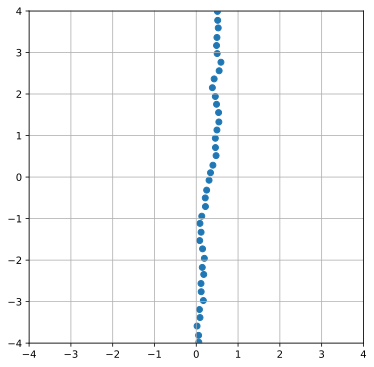

In [677]:
points_count = 40
means = np.hstack([np.zeros(points_count), np.linspace(-4, 4, points_count)])
cov_mat = np.diag(np.hstack([np.full(points_count, 1), np.zeros(points_count) + 0.0001]))
# cov_mat = np.diag(np.hstack([np.full(points_count, 1), np.zeros(points_count) + 0.0001]))

for point_ind in range(points_count - 1):
    for next_point_ind in range(point_ind+1, points_count):
        cross_cov = 0.999 * np.sqrt(cov_mat[point_ind, point_ind]) * np.sqrt(cov_mat[next_point_ind, next_point_ind])
        cross_cov = cross_cov ** (next_point_ind - point_ind)
        cov_mat[point_ind, next_point_ind] = cross_cov
        cov_mat[next_point_ind, point_ind] = cross_cov

# cov_mat += np.eye(len(cov_mat)) * 0.000001
# cov_mat += np.diag(RNG.normal(0, 0.0001, size=len(cov_mat)))

points = RNG.multivariate_normal(
    mean=means, 
    cov=cov_mat)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(6)
fig.set_figheight(6)
ax1.scatter(points[:points_count], points[points_count:])
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.grid(True)

In [684]:
corr = 0.95
np.rad2deg(np.arctan(corr))

np.float64(43.53119928561418)

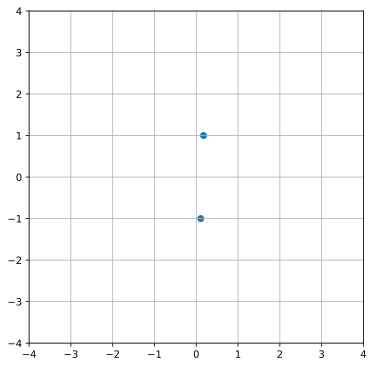

In [761]:
points_count = 2
means = np.zeros(points_count)
cov_mat = np.eye(points_count)

corr = 1
theta = np.rad2deg(np.arctan(corr))
cos_theta = np.cos(theta)
sin_theta = np.sin(theta)

# rot_mat01 = np.eye(len(cov_mat))
# rot_mat01[0,0] = cos_theta
# rot_mat01[0,1] = -sin_theta
# rot_mat01[1,0] = sin_theta
# rot_mat01[1,1] = cos_theta

# rot_mat = rot_mat01

# # rot_mat12 = np.eye(len(cov_mat))
# # rot_mat12[1,1] = cos_theta
# # rot_mat12[1,2] = -sin_theta
# # rot_mat12[2,1] = sin_theta
# # rot_mat12[2,2] = cos_theta

# # rot_mat = rot_mat12 @ rot_mat01

scale_mat = np.eye(points_count)
rot_mat = np.eye(points_count)

for point_ind in range(points_count - 1):
    bond_factor = corr
    
    # sigma_free = cov_mat[point_ind, point_ind]
    # sigma_dep = cov_mat[point_ind+1, point_ind+1]
    # sigma_dep = np.tan(theta) ** 2
    # sigma_free2dep = corr * np.sqrt(sigma_free) * np.sqrt(sigma_dep) * np.sign(theta)
    scale_mat[point_ind+1, point_ind+1] = (1 - bond_factor)
    rot_mat[point_ind, point_ind] = cos_theta
    rot_mat[point_ind, point_ind+1] = -sin_theta
    rot_mat[point_ind+1, point_ind] = sin_theta
    rot_mat[point_ind+1, point_ind+1] = cos_theta

T = rot_mat @ scale_mat

points = RNG.normal(size=points_count)
points = T @ points

# # points = RNG.multivariate_normal(
# #     mean=means, 
# #     cov=cov_mat)

fig, ax1 = plt.subplots(1, 1)
fig.set_figwidth(6)
fig.set_figheight(6)
ax1.scatter(points, np.linspace(-1, 1, points_count))
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.grid(True)

In [517]:
for x in np.linspace(0, 1, 1000):
    try:
        cm1 = np.array(
            [
                [1, 0.99, 0.96],
                [0.99, 1, 0.99],
                [0.96, 0.99, 1],
            ]
        )
        
        np.linalg.cholesky(cm1)
        print(f'kms@ x={x}') 
        break
    except np.linalg.LinAlgError:
        pass

kms@ x=0.960960960960961


In [510]:
eigvals, rot_mat = np.linalg.eig(cm1)
rot_mat @ rot_mat.T

array([[ 1.00000000e+00, -4.44089210e-16,  2.77555756e-17],
       [-4.44089210e-16,  1.00000000e+00,  2.22044605e-16],
       [ 2.77555756e-17,  2.22044605e-16,  1.00000000e+00]])

# Hier norm dist (toy case)

## Ordinal encoding/decoding

In [2577]:
def _encode_ordinal_ohe(value, min_value, max_value):
    bits_count = (max_value - min_value + 1)
    r = np.zeros(bits_count)
    bit_no = value - min_value
    r[bit_no] = 1
    return r
    
def _encode_ordinal_tree(value, min_value, max_value, bit_repertoir, bits_count=0):
    assert len(bit_repertoir) == 2
    assert bit_repertoir[0] != bit_repertoir[1]
    
    encoding = []
    lo_thres, hi_thres, thres = min_value, max_value, (min_value + max_value) / 2

    if not bits_count:
        bits_count = int(np.ceil(np.log2(max_value - min_value + 1)))

    for _ in range(bits_count):
        if value < thres:
            encoding.append(bit_repertoir[0])
            hi_thres = thres
        else:
            encoding.append(bit_repertoir[1])
            lo_thres = thres
            
        thres = (lo_thres + hi_thres) / 2

    return encoding

def _decode_ordinal_ohe(encoding, min_value):
    nzb = np.flatnonzero(encoding > 0)
    # assert len(nzb) == 1
    assert len(nzb) > 0 
    bit_no = nzb[0]
    return int(min_value + bit_no)

def _decode_ordinal_tree(encoding, min_value, max_value, bit_repertoir):
    assert len(bit_repertoir) == 2
    assert bit_repertoir[0] != bit_repertoir[1]
    
    assert max_value >= min_value
    value = (min_value + max_value) / 2

    for bit in encoding:
        if bit == bit_repertoir[0]:
            max_value = value
        else:
            min_value = value

        value = (min_value + max_value) / 2

    return int(np.round(value, decimals=0))

def encode_ordinal(value, min_value, max_value, method, bits_count=0):
    match method:
        case 'ohe':
            return _encode_ordinal_ohe(value, min_value, max_value)
        case 'tree': 
            return _encode_ordinal_tree(value, min_value, max_value, [0, 1], bits_count)
        case 'tree_bipolar':
            return _encode_ordinal_tree(value, min_value, max_value, [-1, +1], bits_count)
        case '_':
            assert False, f'Unkown encoding method \"{method}\"'

def decode_ordinal(encoding, min_value, max_value, method):
    assert max_value >= min_value

    match method:
        case 'ohe':
            return _decode_ordinal_ohe(encoding, min_value)
        case 'tree': 
            return _decode_ordinal_tree(encoding, min_value, max_value, [0, 1])
        case 'tree_bipolar':
            return _decode_ordinal_tree(encoding, min_value, max_value, [-1, +1])
        case '_':
            assert False, f'Unkown decoding method \"{method}\"'

In [2612]:
min_value = 0
max_value = 4

print('OHE encoding. Perfect for conditioning, but requires ad-hoc to sample from Normal distr')
# Natural way to sample from Normal distr = binarize sample, e.g. np.where(sample > .5, 1, 0).
# In OHE binarization could lead to OHE violation: either 0 bits or several bits.
# The reason for OHE violation: mutual exclusivity of bits - only one bit within sample must be ON.
# Possible ad-hoc for OHE = np.argmax(sample)
# In other words. It's hardly possible to sample joint entity (np.r_[encoding, pixels]) from Multivariate normal distr without ad-hoc handling for OHE

for v in range(min_value, max_value + 1):
    encoding = encode_ordinal(v, min_value, max_value, method='ohe')
    v_hat = decode_ordinal(encoding, min_value, max_value, method='ohe')
    print(f'{v} -> {encoding} -> {v_hat}')
    assert v == v_hat, (v, v_hat)

print('Tree encoding. Poor for conditioning, natural to sample from Normal distr')

for v in range(min_value, max_value + 1):
    encoding = encode_ordinal(v, min_value, max_value, method='tree')
    v_hat = decode_ordinal(encoding, min_value, max_value, method='tree')
    print(f'{v} -> {encoding} -> {v_hat}')
    assert v == v_hat, (v, v_hat)

print('Tree bipolar encoding. Poor for conditioning, natural to sample from Normal distr')

for v in range(min_value, max_value + 1):
    encoding = encode_ordinal(v, min_value, max_value, method='tree_bipolar')
    v_hat = decode_ordinal(encoding, min_value, max_value, method='tree_bipolar')
    print(f'{v} -> {encoding} -> {v_hat}')
    assert v == v_hat, (v, v_hat)

OHE encoding. Perfect for conditioning, but very hard to sample from Normal distr
0 -> [1. 0. 0. 0. 0.] -> 0
1 -> [0. 1. 0. 0. 0.] -> 1
2 -> [0. 0. 1. 0. 0.] -> 2
3 -> [0. 0. 0. 1. 0.] -> 3
4 -> [0. 0. 0. 0. 1.] -> 4
Tree encoding. Poor for conditioning, easy to sample from Normal distr
0 -> [0, 0, 0] -> 0
1 -> [0, 1, 0] -> 1
2 -> [1, 0, 0] -> 2
3 -> [1, 1, 0] -> 3
4 -> [1, 1, 1] -> 4
Tree bipolar encoding. Poor for conditioning, easy to sample from Normal distr
0 -> [-1, -1, -1] -> 0
1 -> [-1, 1, -1] -> 1
2 -> [1, -1, -1] -> 2
3 -> [1, 1, -1] -> 3
4 -> [1, 1, 1] -> 4


## Toys arsenal

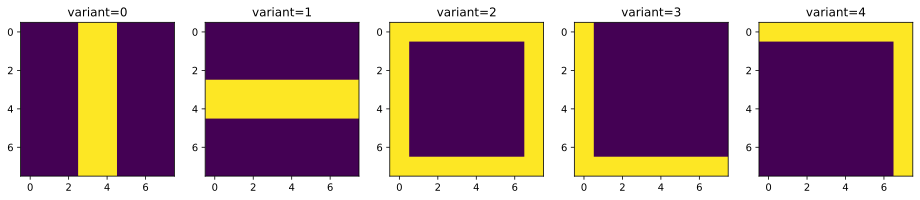

In [2422]:
toys_count = 5
toys = np.zeros((toys_count,8,8))

# Thick vertical bar
toys[0][:,3] = 1
toys[0][:,4] = 1

# Thick horizontal bar
toys[1][3,:] = 1
toys[1][4,:] = 1

# Outer rect
toys[2][0,:] = 1
toys[2][-1,:] = 1
toys[2][:,0] = 1
toys[2][:,-1] = 1

# Bottom L
toys[3][:,0] = 1
toys[3][-1,:] = 1

# Top reflected L
toys[4][0,:] = 1
toys[4][:,-1] = 1

fig, axes = plt.subplots(1, toys.shape[0])
fig.set_figwidth(16)

assert len(axes) == toys.shape[0]

for i, ax in zip(range(toys.shape[0]), axes):
    ax.set_title(f'variant={i}')
    ax.imshow(toys[i]);    

## 0) Sample toy, no encoding, no conditioning

In [2403]:
toy_dataset0 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    toy_dataset0.append(image.ravel())

toy_dataset0 = np.array(toy_dataset0)

In [2404]:
toy_dataset_scaler0 = StandardScaler()
toy_dataset_norm0 = toy_dataset_scaler0.fit_transform(toy_dataset0)
cov_mat0 = np.cov(toy_dataset_norm0, rowvar=False)
assert cov_mat0.shape == (64, 64)
cov_mat0 += np.eye(len(cov_mat0)) * 0.000001

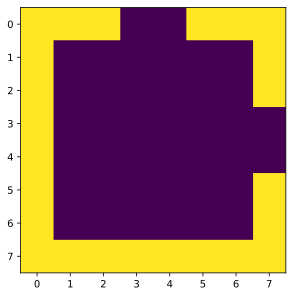

In [2419]:
# chol0 = np.linalg.cholesky(cov_mat0)
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat0)), cov=cov_mat0)
sample = toy_dataset_scaler0.inverse_transform(sample[np.newaxis,:])[0]
sample = np.where(sample > .5, 1, 0)

plt.imshow(vec_to_square_matrix(sample));

Видно, что фигура (toy) сэмплится не радомно. Можно усмотреть ту или иную фигуру. Но при этом часто бывают артефакты. 

## 1) Sample toy, OHE encoding, no conditioning

In [2432]:
toy_dataset1 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    enc_len1 = len(variant_enc)
    toy_dataset1.append(np.r_[variant_enc, image.ravel()])

assert enc_len1 == toys_count
toy_dataset1 = np.array(toy_dataset1)

In [2457]:
toy_dataset_scaler1 = StandardScaler()
toy_dataset_norm1 = toy_dataset_scaler1.fit_transform(toy_dataset1)
cov_mat1 = np.cov(toy_dataset_norm1, rowvar=False)
assert cov_mat1.shape == (enc_len1 + 64, enc_len1 + 64)

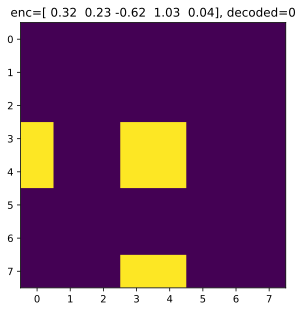

In [2611]:
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat1)), cov=cov_mat1)
sample = toy_dataset_scaler1.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len1]
pixels = sample[enc_len1:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded = decode_ordinal(variant_enc, 0, toys_count-1, method='ohe') # may be very inaccurate
plt.title(f'enc={np.round(variant_enc, 2)}, decoded={decoded}');

Видно, что добавление кодировки в матрицу ковариации не помогает. Фигура (toy) сэмплится пусть и не радомно, но всё равно с ошибками.  
Причина, в том, что вариант кодировки тоже сэмплится с элементом рандомности и поэтому не может влиять сильно на выбор той или иной конфигурации фигуры

## 2) Sample toy, Tree[-1,+1] encoding, no conditioning

In [2460]:
toy_dataset2 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree_bipolar', bits_count=3)
    enc_len2 = len(variant_enc)
    toy_dataset2.append(np.r_[variant_enc, image.ravel()])

assert enc_len2 == 3
toy_dataset2 = np.array(toy_dataset2)

In [2463]:
toy_dataset_scaler2 = StandardScaler()
toy_dataset_norm2 = toy_dataset_scaler2.fit_transform(toy_dataset2)
cov_mat2 = np.cov(toy_dataset_norm2, rowvar=False)
assert cov_mat2.shape == (enc_len2+64, enc_len2+64)

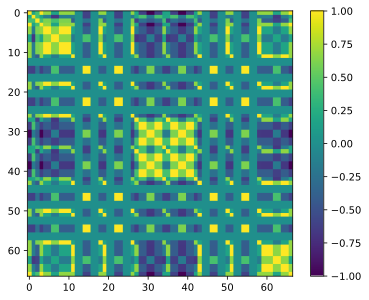

In [2465]:
plt.imshow(cov_mat2);
plt.colorbar();

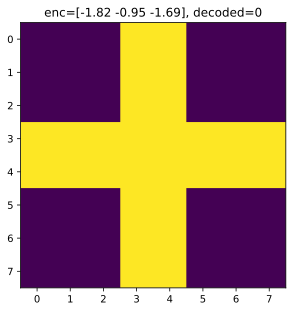

In [2604]:
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat2)), cov=cov_mat2)
sample = toy_dataset_scaler2.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len2]
pixels = sample[enc_len2:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded = decode_ordinal(np.sign(variant_enc), 0, toys_count-1, method='tree_bipolar') # may be very inaccurate
plt.title(f'enc={np.round(variant_enc, 2)}, decoded={decoded}');

Видно, что добавление Tree кодировки в матрицу ковариации тоже не помогает. Фигура (toy) сэмплится пусть и не радомно, но всё равно с ошибками.  
Причина, в том, что:  
а) вариант кодировки тоже сэмплится с элементом рандомности и поэтому не может влиять сильно на выбор той или иной конфигурации фигуры.  
б) ни один из битов в кодировке не определяет уникально ту или иную фигуру. 

## 3) Sample toy, Tree[0,1] encoding, no conditioning

In [2480]:
toy_dataset3 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree', bits_count=3)
    enc_len3 = len(variant_enc)
    toy_dataset3.append(np.r_[variant_enc, image.ravel()])

assert enc_len3 == 3
toy_dataset3 = np.array(toy_dataset3)

In [2481]:
toy_dataset_scaler3 = StandardScaler()
toy_dataset_norm3 = toy_dataset_scaler3.fit_transform(toy_dataset3)
cov_mat3 = np.cov(toy_dataset_norm3, rowvar=False)
assert cov_mat3.shape == (enc_len3+64, enc_len3+64)

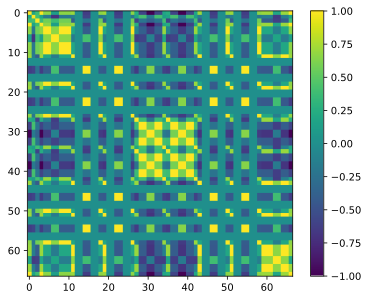

In [2482]:
plt.imshow(cov_mat3);
plt.colorbar();

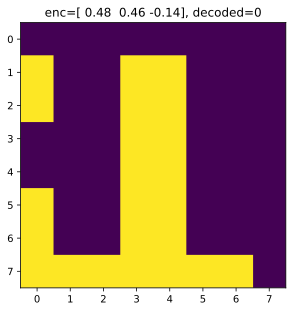

In [2595]:
sample = RNG.multivariate_normal(mean=np.zeros(len(cov_mat3)), cov=cov_mat3)
sample = toy_dataset_scaler3.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len3]
pixels = sample[enc_len3:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded = decode_ordinal(np.where(variant_enc > 0.5, 1, 0), 0, toys_count-1, method='tree') # may be very inaccurate
plt.title(f'enc={np.round(variant_enc, 2)}, decoded={decoded}');

Картина аналогичная Tree-bipolar кодировке

## 4) Sample toy, OHE encoding, conditioning

In [2490]:
toy_dataset4 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    enc_len4 = len(variant_enc)
    toy_dataset4.append(np.r_[variant_enc, image.ravel()])

assert enc_len4 == toys_count
toy_dataset4 = np.array(toy_dataset4)

In [2491]:
toy_dataset_scaler4 = StandardScaler()
toy_dataset_norm4 = toy_dataset_scaler4.fit_transform(toy_dataset4)
cov_mat4 = np.cov(toy_dataset_norm4, rowvar=False)
assert cov_mat4.shape == (enc_len4+64, enc_len4+64)

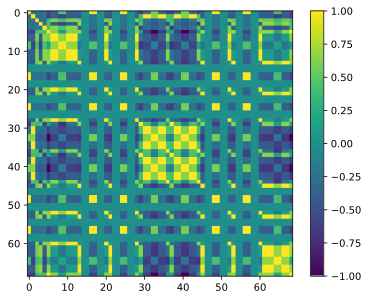

In [2492]:
plt.imshow(cov_mat4);
plt.colorbar();

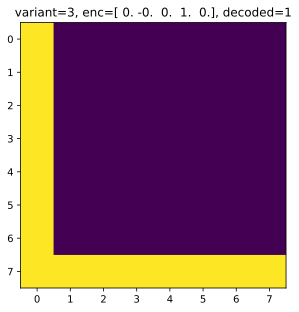

In [2552]:
variant = 3
variant_enc = encode_ordinal(variant, 0, toys_count-1, method='ohe') # topdown conditioning (variant -> pixels)
variant_enc_plus_dummy = np.r_[variant_enc, np.zeros(64)]
variant_enc_plus_dummy = toy_dataset_scaler4.transform(variant_enc_plus_dummy[np.newaxis,:])[0]
variant_enc = variant_enc_plus_dummy[:enc_len4]

Σ11 = cov_mat4[:enc_len4,:enc_len4] + np.eye(enc_len4) * 0.0000001 # tikhonov regularization to avoid singular matrix
Σ12 = cov_mat4[:enc_len4,enc_len4:]
solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
μ2 = solved @ variant_enc
Σ22 = cov_mat4[enc_len4:,enc_len4:]
Σ2 = Σ22 - (solved @ Σ12)

sample = RNG.multivariate_normal(mean=μ2, cov=Σ2)
sample = np.r_[variant_enc, sample]
sample = toy_dataset_scaler4.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len4]
pixels = sample[enc_len4:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
plt.title(f'variant={variant}, enc={np.round(variant_enc, 2)}, decoded={decode_ordinal(variant_enc, 0, toys_count-1, method='ohe')}');

С OHE-кодировкой и кондишнингом фигура восстанавливается корректно.  

## 5) Sample toy, Tree[0,1] encoding, conditioning

In [2533]:
toy_dataset5 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree')
    enc_len5 = len(variant_enc)
    toy_dataset5.append(np.r_[variant_enc, image.ravel()])

assert enc_len5 == 3
toy_dataset5 = np.array(toy_dataset5)

In [2534]:
toy_dataset_scaler5 = StandardScaler()
toy_dataset_norm5 = toy_dataset_scaler5.fit_transform(toy_dataset5)
cov_mat5 = np.cov(toy_dataset_norm5, rowvar=False)
assert cov_mat5.shape == (enc_len5+64, enc_len5+64)

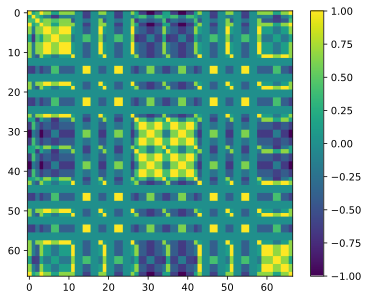

In [2535]:
plt.imshow(cov_mat5);
plt.colorbar();

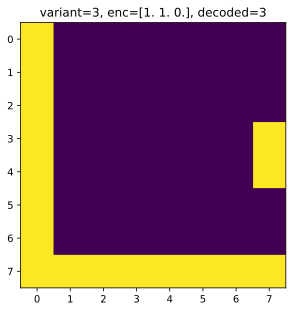

In [2553]:
variant = 3
variant_enc = encode_ordinal(variant, 0, toys_count-1, method='tree') # topdown conditioning (variant -> pixels)
variant_enc_plus_dummy = np.r_[variant_enc, np.zeros(64)]
variant_enc_plus_dummy = toy_dataset_scaler5.transform(variant_enc_plus_dummy[np.newaxis,:])[0]
variant_enc = variant_enc_plus_dummy[:enc_len5]

Σ11 = cov_mat5[:enc_len5,:enc_len5] + np.eye(enc_len5) * 0.0000001 # tikhonov regularization to avoid singular matrix
Σ12 = cov_mat5[:enc_len5,enc_len5:]
solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
μ2 = solved @ variant_enc
Σ22 = cov_mat5[enc_len5:,enc_len5:]
Σ2 = Σ22 - (solved @ Σ12)

sample = RNG.multivariate_normal(mean=μ2, cov=Σ2)
sample = np.r_[variant_enc, sample]
sample = toy_dataset_scaler5.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len5]
pixels = sample[enc_len5:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
plt.title(f'variant={variant}, enc={np.round(variant_enc, 2)}, decoded={decode_ordinal(variant_enc, 0, toys_count-1, method='tree')}');

С Tree-кодировкой и кондишнингом фигура восстанавливается, но не всегда корректно.  
Вывод: нужен уникальный бит, чтобы ковариационная матрица могла "зацепиться" за этот факт. В OHE-кодировке такие (уникальные) биты есть, в Tree кодирвке - нет (один и тот же бит может использоваться в разных кодах)

## 6) Sample toy, OHE+Tree[0,1] encoding, conditioning

In [2554]:
toy_dataset6 = []
variants = RNG.choice(np.arange(5), size=1000)

for variant in variants:
    image = toys[variant]
    variant_enc_tree = encode_ordinal(variant, 0, toys_count-1, method='tree') 
    variant_enc_ohe = encode_ordinal(variant, 0, toys_count-1, method='ohe')
    variant_enc = np.r_[variant_enc_tree, variant_enc_ohe]
    enc_len6 = len(variant_enc)
    toy_dataset6.append(np.r_[variant_enc, image.ravel()])

toy_dataset6 = np.array(toy_dataset6)
assert toy_dataset6.shape[1] == 64 + enc_len6

In [2556]:
toy_dataset_scaler6 = StandardScaler()
toy_dataset_norm6 = toy_dataset_scaler6.fit_transform(toy_dataset6)
cov_mat6 = np.cov(toy_dataset_norm6, rowvar=False)
assert cov_mat6.shape == (64+enc_len6, 64+enc_len6)

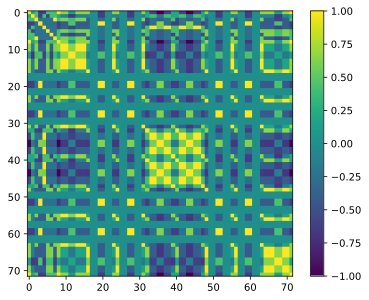

In [2557]:
plt.imshow(cov_mat6);
plt.colorbar();

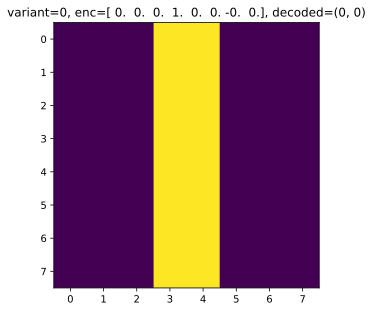

In [2581]:
variant = 0
# topdown conditioning (variant -> pixels)
variant_enc_tree = encode_ordinal(variant, 0, toys_count-1, method='tree')
variant_enc_ohe = encode_ordinal(variant, 0, toys_count-1, method='ohe') 
variant_enc = np.r_[variant_enc_tree, variant_enc_ohe]
variant_enc_plus_dummy = np.r_[variant_enc, np.zeros(64)]
variant_enc_plus_dummy = toy_dataset_scaler6.transform(variant_enc_plus_dummy[np.newaxis,:])[0]
variant_enc = variant_enc_plus_dummy[:enc_len6]

Σ11 = cov_mat6[:enc_len6,:enc_len6] + np.eye(enc_len6) * 0.0000001 # tikhonov regularization to avoid singular matrix
Σ12 = cov_mat6[:enc_len6,enc_len6:]
solved = sp.linalg.solve(Σ11, Σ12, assume_a='pos').T
μ2 = solved @ variant_enc
Σ22 = cov_mat6[enc_len6:,enc_len6:]
Σ2 = Σ22 - (solved @ Σ12)

sample = RNG.multivariate_normal(mean=μ2, cov=Σ2)
sample = np.r_[variant_enc, sample]
sample = toy_dataset_scaler6.inverse_transform(sample[np.newaxis,:])[0]
variant_enc = sample[:enc_len6]
pixels = sample[enc_len6:]
pixels = np.where(pixels > .5, 1, 0)

plt.imshow(vec_to_square_matrix(pixels));
decoded_tree = decode_ordinal(variant_enc[:3], 0, toys_count-1, method='tree')
decoded_ohe = decode_ordinal(variant_enc[3:], 0, toys_count-1, method='ohe')
plt.title(f'variant={variant}, enc={np.round(variant_enc, 2)}, decoded={decoded_tree, decoded_ohe}');

Со смешанной кодировкой (Tree + OHE) и кондишнингом фигура восстанавливается корректно.  
Вывод: нужен уникальный бит, чтобы ковариационная матрица могла "зацепиться" за этот факт. При этом неважно, что другие биты в кодировке могут быть "мусорными"

In [ ]:
# Random vector + various bits coocurence as features == equialent of OHE

# Hier norm distr

In [808]:
def calc_seq_ipxy(sequences, si_ind_dict):
    res = []  # transcript of sequences with full interpolation by xy 
        
    for sequence in sequences:
        xy_sequence = get_xy_sequence(sequence, si_ind_dict)
        xy_sequence_fwd = np.roll(xy_sequence, -1, axis=0)
        vec_sequence = xy_sequence_fwd - xy_sequence
        vec_sequence[-1,:] = 0 # get rid of reciprocal vector which connects tail to tip
        vec_len_sequence = np.linalg.norm(vec_sequence, axis=1)
        vec_len_sequence_nozero = np.where(vec_len_sequence != 0, vec_len_sequence, 1e-6) # prevent 0 len vectors
        norm_vec_sequence = (vec_sequence.T / vec_len_sequence_nozero).T
        vec_len_sequence = np.round(vec_len_sequence, decimals=0).astype(int)
        
        assert len(sequence) == vec_sequence.shape[0]
        assert len(sequence) == vec_len_sequence.shape[0]
        assert len(sequence) == norm_vec_sequence.shape[0]
        
        for pt, pt_to, norm_vec, vec_len in zip(xy_sequence, xy_sequence_fwd, norm_vec_sequence, vec_len_sequence):
            if vec_len <= 0:
                continue

            pts = pt + (np.arange(vec_len) * norm_vec[np.newaxis,:].T).T # path interpolation
            pts = np.round(pts, decimals=0).astype(int)
            res.append(pts)
            res.append(pt_to)

    assert res
    res = np.vstack(res)
    return res

def calc_seq_bv(seq_xy):
    assert np.all((seq_xy >= 0) & (seq_xy < config.sample_size))
    ind_seq = (seq_xy @ np.array([1, config.sample_size])).astype(int)
    bitmap_vec = np.zeros((config.sample_size, config.sample_size), dtype='f').ravel()
    bitmap_vec[ind_seq] = 1
    return bitmap_vec

In [1351]:
IMAGES_COUNT = 1000
images = df_train_images[df_train_images.value == '5'][:IMAGES_COUNT]

BLOCK_SIZE = 8
block_coords = []

for i in range(0, config.sample_size, BLOCK_SIZE):
    for j in range(0, config.sample_size, BLOCK_SIZE):
        coords = np.s_[i:i+BLOCK_SIZE,j:j+BLOCK_SIZE]
        block_coords.append(coords)

blocks_count = len(block_coords)
assert blocks_count == 256

macroblock_dataset = []
block_dataset = [[] for _ in range(blocks_count)]

for image in tqdm(images.itertuples(), total=len(images)):
    sequences = pickle.loads(image.inner_sequences)
    si_ind_dict = pickle.loads(image.inner_si_ind_dict)
    ipxy = calc_seq_ipxy(sequences, si_ind_dict)
    bv = calc_seq_bv(ipxy).reshape(config.sample_size, -1) # bitmap vec
    macroblock_row = []

    for block_ind, coords in enumerate(block_coords):
        block = bv[coords].ravel()
        assert len(block) == 64
        assert np.all(np.isin(block, [0,1]))
        macroblock_row.append(block.sum())
        block_dataset[block_ind].append(block)

    macroblock_dataset.append(macroblock_row)

macroblock_dataset_orig = np.array(macroblock_dataset)
block_dataset_orig = np.array(block_dataset)

  0%|          | 0/898 [00:00<?, ?it/s]

In [1358]:
macroblock_scaler = StandardScaler(with_mean=True, with_std=True)
macroblock_dataset = macroblock_scaler.fit_transform(macroblock_dataset_orig);

block_scalers = []
block_dataset = block_dataset_orig.copy()

for ind, blocks in enumerate(block_dataset):
    block_scaler = StandardScaler()
    block_dataset[ind] = block_scaler.fit_transform(blocks)
    block_scalers.append(block_scaler)
    # assert ind != 62

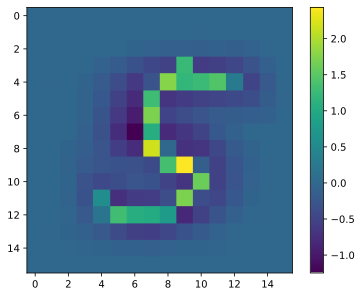

In [1359]:
ind = RNG.choice(len(macroblock_dataset))
image = macroblock_dataset[ind]

plt.imshow(vec_to_square_matrix(image))
plt.colorbar();

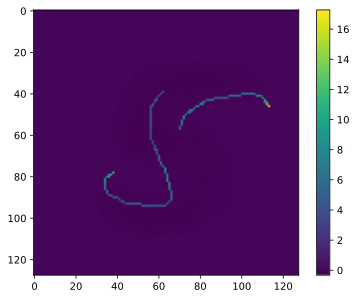

In [1360]:
image = np.zeros((config.sample_size, config.sample_size))
dataset_row_ind = RNG.choice(len(block_dataset))

for block_ind, blocks in enumerate(block_dataset):
    where_to = block_coords[block_ind]
    block_sample = blocks[dataset_row_ind]
    # if np.any(block_sample>10):
    #     assert False
    image[where_to] = block_sample.reshape(BLOCK_SIZE, -1)

plt.imshow(image)
plt.colorbar();

156.17391485652604


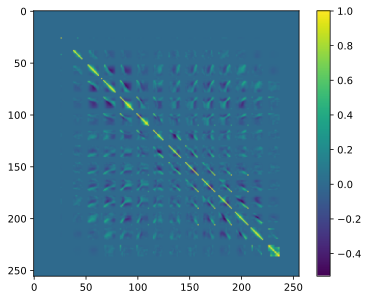

In [1361]:
Σ_macro = np.cov(macroblock_dataset, rowvar=False)
print(np.linalg.trace(Σ_macro))
plt.imshow(Σ_macro)
plt.colorbar();

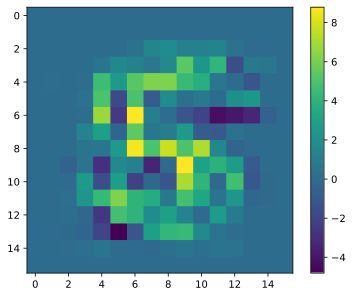

In [1364]:
sample = RNG.multivariate_normal(
    # mean=macroblock_means,
    mean=np.zeros(len(Σ_macro)),
    cov=Σ_macro)
# sample += macroblock_means
sample = macroblock_scaler.inverse_transform(sample[np.newaxis,:])[0]
plt.imshow(vec_to_square_matrix(sample))#, cmap='turbo')
plt.colorbar();

In [1365]:
Σ_contextual_block_size = len(Σ_macro) + BLOCK_SIZE**2
Σ_blocks1 = []
Σ_blocks2 = []
chol_blocks1 = []
chol_blocks2 = []

make_positive_definite1 = np.eye(Σ_contextual_block_size) * 0.000001
make_positive_definite2 = np.eye(BLOCK_SIZE**2) * 0.000001

for block_ind, block in tqdm(enumerate(block_dataset), total=len(block_dataset)):
    concat_dataset = np.c_[macroblock_dataset, block]
    Σ_block = np.cov(concat_dataset, rowvar=False)
    assert np.all(np.isclose(Σ_block[:len(Σ_macro),:len(Σ_macro)], Σ_macro))
    Σ_block += make_positive_definite1
    Σ_blocks1.append(Σ_block)
    chol_block = np.linalg.cholesky(Σ_block)
    chol_blocks1.append(chol_block)

    Σ_block = np.cov(block, rowvar=False)
    Σ_block += make_positive_definite2
    Σ_blocks2.append(Σ_block)
    chol_block = np.linalg.cholesky(Σ_block)
    chol_blocks2.append(chol_block)

  0%|          | 0/256 [00:00<?, ?it/s]

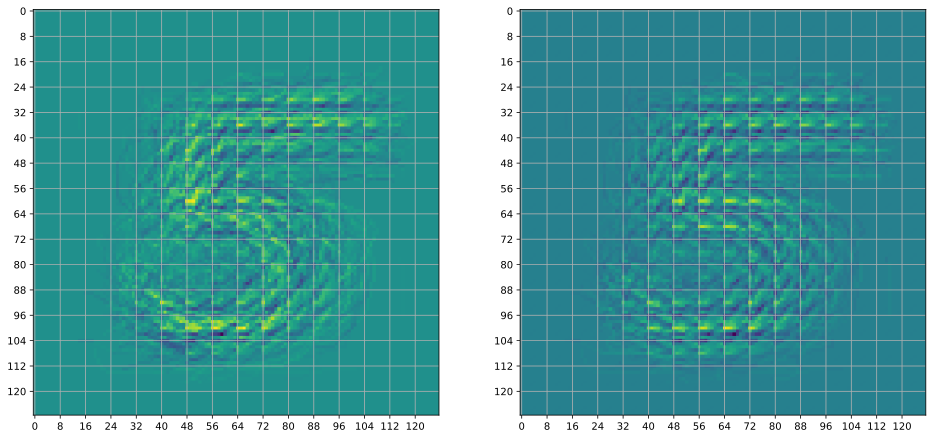

In [1404]:
image1 = np.zeros((config.sample_size, config.sample_size))
image2 = np.zeros((config.sample_size, config.sample_size))

seed1 = RNG.multivariate_normal(
    mean=np.zeros(Σ_contextual_block_size),
    cov=np.eye(Σ_contextual_block_size))

seed2 = seed1[len(Σ_macro):]

for block_ind, (chol_block1, chol_block2) in enumerate(zip(chol_blocks1, chol_blocks2)):
    where_to = block_coords[block_ind]
    
    block_sample_raw = chol_block1 @ seed1
    block_sample = block_sample_raw[len(Σ_macro):]
    # block_sample += block_means[block_ind]
    block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
    block_sample = block_sample.reshape(BLOCK_SIZE, -1)
    image1[where_to] = block_sample

    block_sample = chol_block2 @ seed2
    # block_sample += block_means[block_ind]
    block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
    block_sample = block_sample.reshape(BLOCK_SIZE, -1)
    image2[where_to] = block_sample

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)

# binarize = lambda i: np.where(i > 0.5, 1, 0)
binarize = lambda i: i

ax1.imshow(binarize(image1))
ax1.grid(True)
ax1.set_xticks(np.arange(0, config.sample_size, BLOCK_SIZE))
ax1.set_yticks(np.arange(0, config.sample_size, BLOCK_SIZE))

ax2.imshow(binarize(image2))
ax2.grid(True);
ax2.set_xticks(np.arange(0, config.sample_size, BLOCK_SIZE))
ax2.set_yticks(np.arange(0, config.sample_size, BLOCK_SIZE));

# plt.colorbar(shrink=0.8);

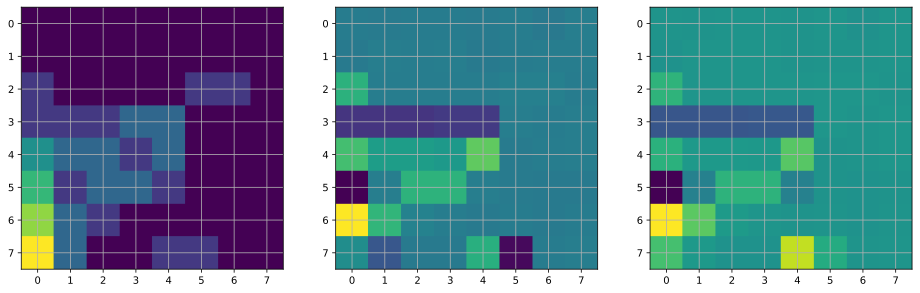

In [1387]:
# seed1 = RNG.multivariate_normal(
#     mean=np.zeros(Σ_contextual_block_size),
#     cov=np.eye(Σ_contextual_block_size))

# seed2 = seed1[len(Σ_macro):]

i = 7
j = 6
block_ind = BLOCK_SIZE*i+j

chol_block1 = chol_blocks1[block_ind]
block_sample_raw = chol_block1 @ seed1
block_sample = block_sample_raw[len(Σ_macro):]
# block_sample += block_means[block_ind]
block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
image1 = block_sample.reshape(BLOCK_SIZE, -1)

chol_block2 = chol_blocks2[block_ind]
block_sample = chol_block2 @ seed2
# block_sample += block_means[block_ind]
block_sample = block_scalers[block_ind].inverse_transform(block_sample[np.newaxis,:])[0]
image2 = block_sample.reshape(BLOCK_SIZE, -1)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)

ax0.imshow(vec_to_square_matrix(block_scalers[block_ind].mean_))
ax0.grid(True)
ax0.set_xticks(np.arange(BLOCK_SIZE))
ax0.set_yticks(np.arange(BLOCK_SIZE));

ax1.imshow(image1)
ax1.grid(True)
ax1.set_xticks(np.arange(BLOCK_SIZE))
ax1.set_yticks(np.arange(BLOCK_SIZE));

im = ax2.imshow(image2)
ax2.grid(True);
ax2.set_xticks(np.arange(BLOCK_SIZE))
ax2.set_yticks(np.arange(BLOCK_SIZE));
# fig.colorbar(im, ax=ax2, shrink=0.6);

In [1400]:
np.unique_counts(block_dataset_orig[block_ind][:,24])

UniqueCountsResult(values=array([0., 1.], dtype=float32), counts=array([897,   1]))

In [1389]:
np.round(vec_to_square_matrix(block_scalers[block_ind].mean_), 3)

array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.001, 0.   , 0.   , 0.   , 0.   , 0.001, 0.001, 0.   ],
       [0.001, 0.001, 0.001, 0.002, 0.002, 0.   , 0.   , 0.   ],
       [0.003, 0.002, 0.002, 0.001, 0.002, 0.   , 0.   , 0.   ],
       [0.004, 0.001, 0.002, 0.002, 0.001, 0.   , 0.   , 0.   ],
       [0.006, 0.002, 0.001, 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.007, 0.002, 0.   , 0.   , 0.001, 0.001, 0.   , 0.   ]])

In [1390]:
np.round(vec_to_square_matrix(block_scalers[block_ind].scale_), 3)

array([[1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ],
       [1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ],
       [0.033, 1.   , 1.   , 1.   , 1.   , 0.033, 0.033, 1.   ],
       [0.033, 0.033, 0.033, 0.047, 0.047, 1.   , 1.   , 1.   ],
       [0.058, 0.047, 0.047, 0.033, 0.047, 1.   , 1.   , 1.   ],
       [0.067, 0.033, 0.047, 0.047, 0.033, 1.   , 1.   , 1.   ],
       [0.074, 0.047, 0.033, 1.   , 1.   , 1.   , 1.   , 1.   ],
       [0.081, 0.047, 1.   , 1.   , 0.033, 0.033, 1.   , 1.   ]])

In [1391]:
np.round(image1, 2)

array([[-0.  , -0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [-0.  ,  0.  ,  0.  ,  0.  , -0.  , -0.  ,  0.  ,  0.  ],
       [ 0.04,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ],
       [-0.04, -0.04, -0.04, -0.04, -0.04,  0.  ,  0.  ,  0.  ],
       [ 0.05,  0.02,  0.02,  0.02,  0.06, -0.  ,  0.  ,  0.  ],
       [-0.07,  0.  ,  0.04,  0.04,  0.  , -0.  , -0.  , -0.  ],
       [ 0.1 ,  0.04,  0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [ 0.01, -0.02, -0.  , -0.  ,  0.04, -0.07, -0.  ,  0.  ]])

In [1392]:
np.round(image2, 2)

array([[-0.  , -0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [-0.  ,  0.  ,  0.  ,  0.  , -0.  , -0.  ,  0.  ,  0.  ],
       [ 0.03,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ],
       [-0.06, -0.06, -0.06, -0.05, -0.05,  0.  ,  0.  ,  0.  ],
       [ 0.03,  0.01,  0.01,  0.  ,  0.05, -0.  ,  0.  ,  0.  ],
       [-0.11, -0.02,  0.03,  0.03, -0.02, -0.  , -0.  , -0.  ],
       [ 0.11,  0.05,  0.01,  0.  , -0.  ,  0.  , -0.  ,  0.  ],
       [ 0.04,  0.01, -0.  , -0.  ,  0.09,  0.02, -0.  ,  0.  ]])

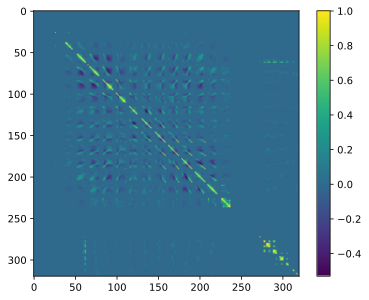

In [1316]:
Σ_block = Σ_blocks1[block_ind]
plt.imshow(Σ_block)
plt.colorbar()